In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
files = [
    "benchall-AwareBVH-Twist-dragon-217816-2026-04-06.csv",
    "benchall-DynamicBVH-Twist-dragon-217816-2026-04-06.csv",
    "benchall-KineticBVH-Twist-dragon-217816-2026-04-06.csv",
    "benchall-RefitRotate-Twist-dragon-217816-2026-04-06.csv"
]

In [143]:
labels = ["Aware BVH", "Dynamic BVH", "Kinetic BVH", "Refit Rotate BVH"]
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b']

In [144]:
metrics = ['deformMs', 'updateMs', 'queryMs', 'totalMs']
titles = ['Deformation Time', 'Update Time', 'Query Time', 'Total Time']

In [145]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")

In [146]:
def get_averaged_line(df, metric_col):
    common_x = np.linspace(0, 100, 300)
    all_y_interpolated = []
    
    for run_id in df['run'].unique():
        run_data = df[df['run'] == run_id].sort_values('cycleProgress')
        x_vals = run_data['cycleProgress'] * 100
        y_vals = run_data[metric_col]
        y_interp = np.interp(common_x, x_vals, y_vals)
        all_y_interpolated.append(y_interp)
        
    avg_y = np.mean(all_y_interpolated, axis=0)
    return common_x, avg_y

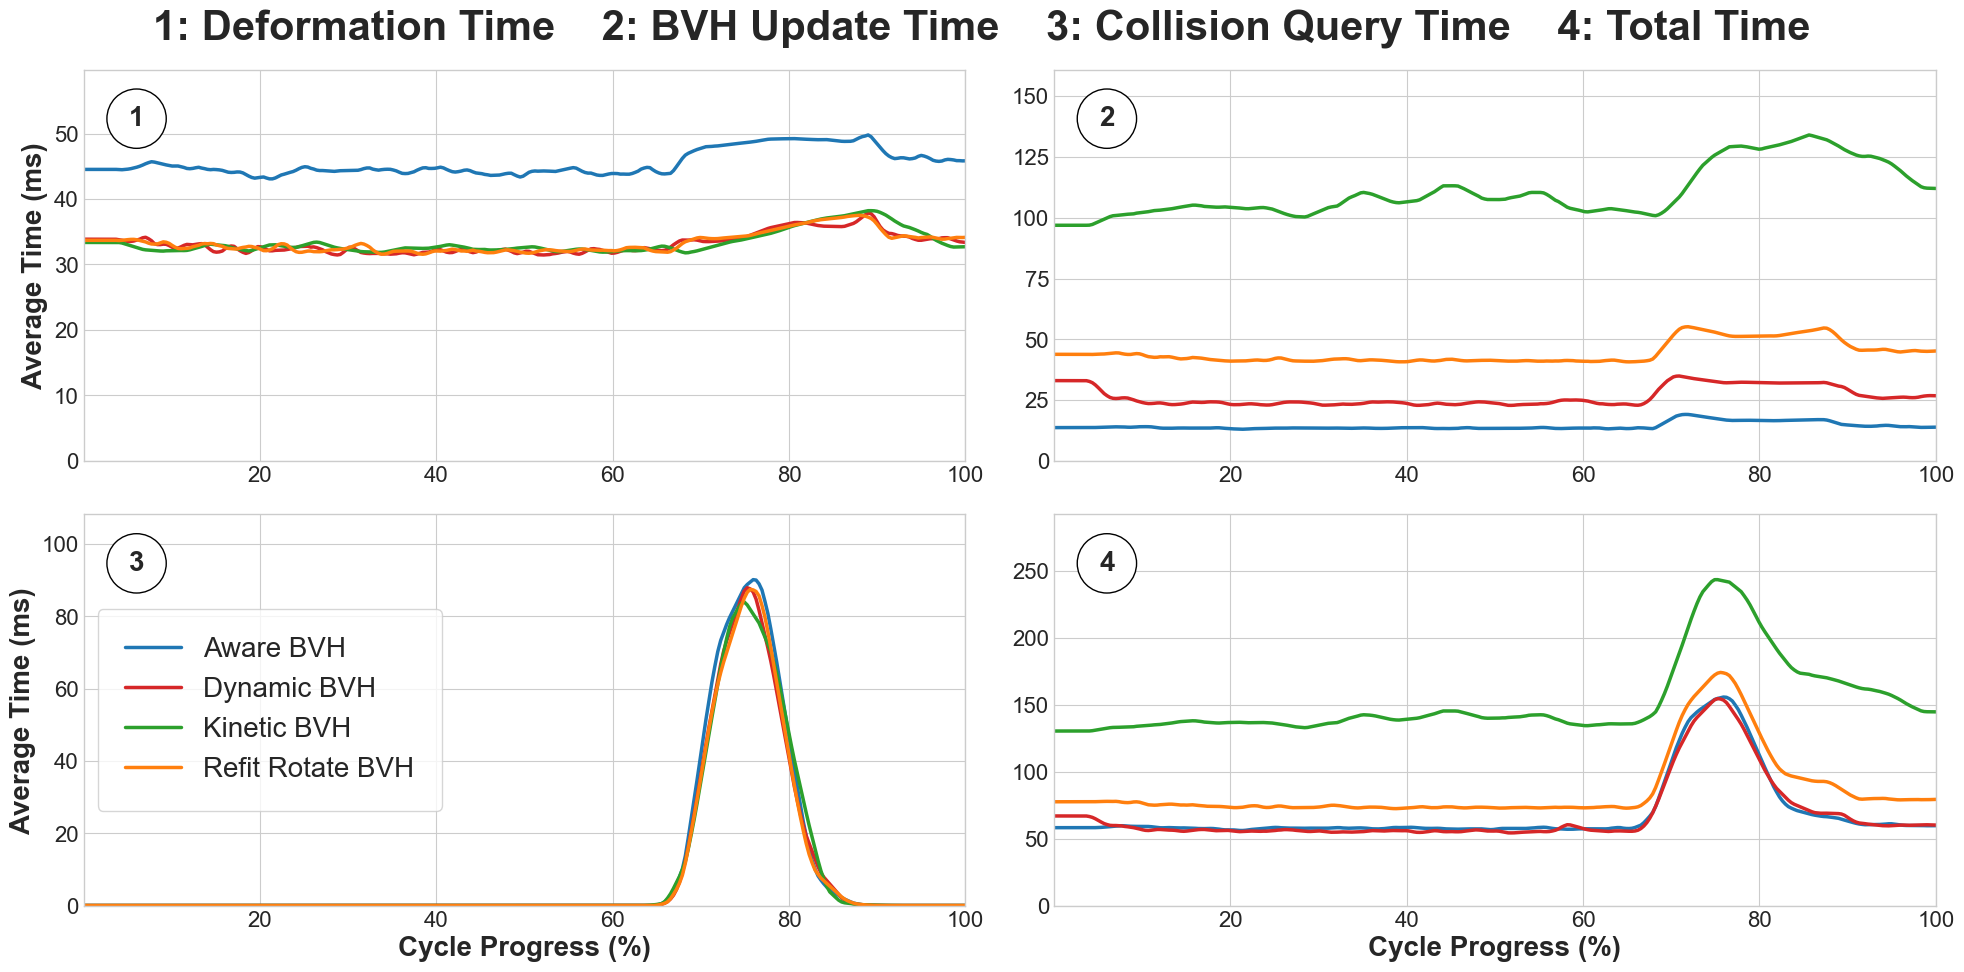

In [147]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

definition_text = "1: Deformation Time    2: BVH Update Time    3: Collision Query Time    4: Total Time"
fig.suptitle(definition_text, fontsize=30, fontweight='bold', y=0.98)

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    max_y = 0
    
    for j, file_path in enumerate(files):
        df = pd.read_csv(file_path, comment='#')
        x, y = get_averaged_line(df, metric)
        ax.plot(x, y, linestyle='-', linewidth=2.5, color=colors[j % len(colors)], label=labels[j])
        
        current_max = np.max(y)
        if current_max > max_y:
            max_y = current_max
            
    ax.text(0.060, 0.875, f"{i+1}", transform=ax.transAxes, 
            fontsize=20, fontweight='bold', va='center', ha='center',
            bbox=dict(facecolor='white', alpha=1.0, edgecolor='black', boxstyle='circle, pad=0.6'))
    
    if i >= 2:
        ax.set_xlabel('Cycle Progress (%)', fontsize=20, fontweight='bold')
    else:
        ax.set_xlabel('')
        
    if i % 2 == 0:
        ax.set_ylabel('Average Time (ms)', fontsize=20, fontweight='bold')
    else:
        ax.set_ylabel('')
        
    ax.set_xlim(0, 100)
    
    if max_y > 0:
        ax.set_ylim(0, max_y * 1.2)
    else:
        ax.set_ylim(bottom=0)
    
    x_ticks = [tick for tick in ax.get_xticks() if tick != 0]
    x_tick_labels = [f'{int(tick)}' for tick in x_ticks]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_tick_labels)
      
    ax.tick_params(axis='both', labelsize=16)
    
    if i == 2:
        ax.legend(frameon=True, fontsize=20, loc='center left', borderpad=1)

plt.tight_layout(pad=2.0)
plt.subplots_adjust(top=0.92) 
# plt.savefig('__update_time.pdf', dpi=300, bbox_inches='tight')
plt.show()  